# Модели кластеризации на примере обработки изображений японских иероглифов

Требования для сдачи лабораторной работы:
1. Использовать набор данных стандарта MNIST
2. Анализ датасета
3. Анализ каждого класса по отдельности
...

## Скачивание и загрузка датасета Kuzushiji-MNIST

In [32]:
# Установка библиотеки openml
%pip install openml

Note: you may need to restart the kernel to use updated packages.


In [33]:
# Импорт библиотек
from dotenv import load_dotenv
import os

from scipy.io import arff
from PIL import Image
import numpy as np
import pandas as pd
import openml
import matplotlib.pyplot as plt

In [34]:
 # Загружаем переменные окружения из .env файла
print("Переменные окружения загружены из .env файла") if load_dotenv() else print("Не удалось загрузить переменные окружения из .env файла")

Переменные окружения загружены из .env файла


In [35]:
# Загрузка датасета по названию
openml_api_key = os.getenv("OPENML_API_KEY")
openml.config.apikey = openml_api_key

df = openml.datasets.get_dataset("Kuzushiji-MNIST")
df

OpenML Dataset
Name.........: Kuzushiji-MNIST
Version......: 1
Format.......: arff
Upload Date..: 2019-07-23 11:27:57
Licence......: CC BY-SA 4.0
Download URL.: https://openml.org/data/v1/download/21388379/Kuzushiji-MNIST.arff
OpenML URL...: https://www.openml.org/d/41982
# of features: None

In [36]:
# Загрузка датасета из файла
df_arff = arff.loadarff("dataset.arff")
df = pd.DataFrame(df_arff[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel-0000 to class
dtypes: float64(784), object(1)
memory usage: 419.2+ MB


In [37]:
df.head(5)

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783,class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,255.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'8'
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'7'
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'0'
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,164.0,...,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'1'
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'4'


## Изучение датасета

In [38]:
plt.style.use('dark_background') # тёмная тема 😎

In [39]:
# число классов, размер изображений, количество объектов...
print(f"Число классов: {df['class'].nunique()}")
print(f"Размер изображений: {((df.shape[1] - 1) ** 0.5)}x{((df.shape[1] - 1) ** 0.5)} пикселей")
print(f"Количество объектов: {len(df)}")
print(f"Распределение классов: {df['class'].value_counts()}")

Число классов: 10
Размер изображений: 28.0x28.0 пикселей
Количество объектов: 70000
Распределение классов: class
b'8'    7000
b'7'    7000
b'0'    7000
b'1'    7000
b'4'    7000
b'2'    7000
b'5'    7000
b'6'    7000
b'9'    7000
b'3'    7000
Name: count, dtype: int64


In [40]:
df.describe()

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0774,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.301243,0.741543,1.249814,2.179300,3.693329,5.875200,8.773643,12.551114,16.945986,21.871629,...,35.132743,25.873400,18.033886,12.375786,8.735043,6.299857,4.600371,3.092871,1.610871,0.505957
std,6.156516,10.437733,13.743910,18.550983,24.260307,30.348452,36.944220,44.025184,50.908111,57.488900,...,75.074359,65.537368,55.269795,45.881976,38.601974,32.606155,27.867166,22.711429,15.786300,7.623220
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [41]:
print(f"Один пиксель изображения кодируется {df.iloc[:, :-1].max().max().astype(int) + 1} уровнями цвета")

Один пиксель изображения кодируется 256 уровнями цвета


То есть для иероглифов используется 8 битовое кодирование

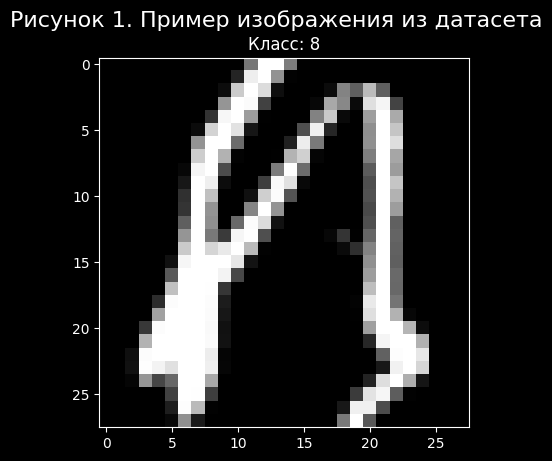

In [42]:
get_image = lambda row: row.drop('class').values.reshape(28, 28).astype(int)
get_label = lambda row: row['class'].decode("utf-8") if isinstance(row['class'], bytes) else row['class']

# Первая картинка в датасете
imgplot = get_image(df.iloc[0])
plt.imshow(imgplot, cmap="gray")
plt.title(f"Класс: {get_label(df.iloc[0])}")
plt.suptitle("Рисунок 1. Пример изображения из датасета", fontsize=16)
plt.show()

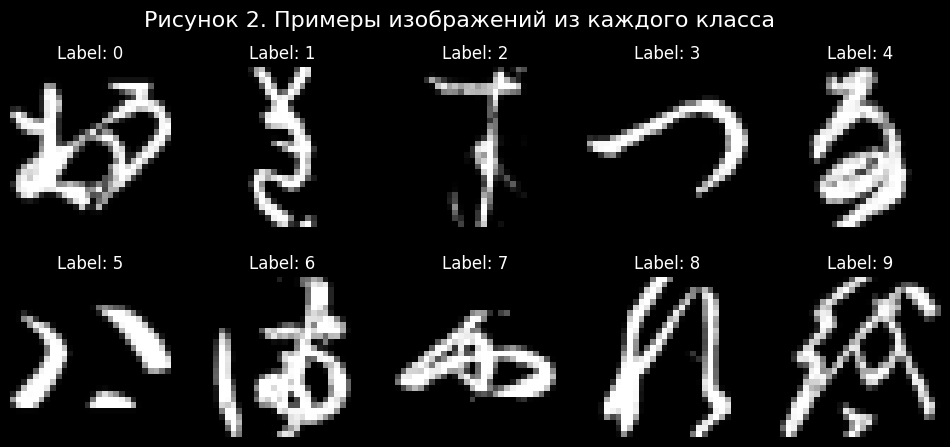

In [43]:
# Визуализация изображений
def show_df_classes(df: pd.DataFrame, header: str) -> None:
    df_each_class = df.groupby('class').first().reset_index()  # Получаем по одному примеру для каждого класса

    class_list_encoded = df['class'].unique()
    if isinstance(class_list_encoded[0], bytes):  # Проверяем, являются ли метки байтовыми строками
        class_list = [label.decode("utf-8") for label in class_list_encoded]
    else:
        class_list = class_list_encoded.tolist()
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(header, fontsize=16)

    for i, ax in enumerate(axes.flatten()): # оси сглажены в одномерный массив для вывода через imshow
        datapoint = df_each_class.iloc[i]
        label = get_label(datapoint)
        classes_to_show = class_list
        
        if label in classes_to_show: 
            ax.imshow(get_image(datapoint), cmap="gray")
            ax.set_title(f"Label: {label}")
            ax.axis("off")
            classes_to_show.remove(label)

    plt.show()

show_df_classes(df, "Рисунок 2. Примеры изображений из каждого класса")

Сопоставим иероглифы с картинкой из оригинальной статьи, в которой, в том числе, описывается создание датасета https://arxiv.org/pdf/1812.01718. 

Также рассмотрим как эти иероглифы выглядят в современном японском письме (https://kanadojo.com/academy/complete-hiragana-chart-pronunciation). На изображении 4, в общей таблице выделены насыщенным контуром рассматриваемые 10 иероглифов.

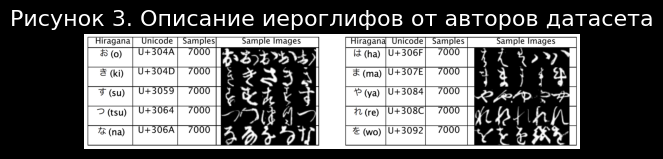

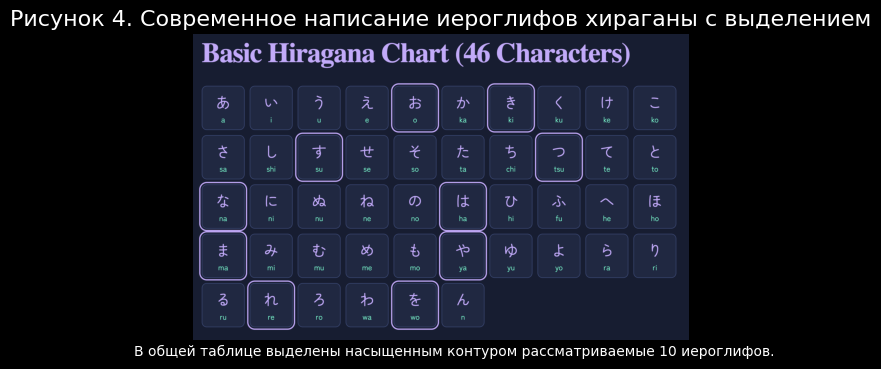

In [44]:
pwd = os.getcwd()

plt.imshow(np.asarray(Image.open(f'{pwd}/characters from reference paper.png')))
plt.axis("off")
plt.title("Рисунок 3. Описание иероглифов от авторов датасета", fontsize=16)
plt.show()

# Источник: https://kanadojo.com/academy/complete-hiragana-chart-pronunciation
plt.imshow(np.asarray(Image.open(f"{pwd}/Hiragana Chart with highlighted characters.png")))
plt.text(-250, 1370,"В общей таблице выделены насыщенным контуром рассматриваемые 10 иероглифов.")
plt.axis("off")
plt.title("Рисунок 4. Современное написание иероглифов хираганы с выделением", fontsize=16)
plt.show()

In [45]:
# Маппинг числовых меток Kuzushiji-MNIST на иероглифы хираганы
# kuzushiji_classes = {
#     '0': 'お(o)', '1': 'き(ki)', '2': 'す(su)', '3': 'つ(tsu)', '4': 'な(na)',
#     '5': 'は(ha)', '6': 'ま(ma)', '7': 'や(ya)', '8': 'れ(re)', '9': 'を(wo)'
# }

kuzushiji_classes = {
    '0': 'o', '1': 'ki', '2': 'su', '3': 'tsu', '4': 'na',
    '5': 'ha', '6': 'ma', '7': 'ya', '8': 're', '9': 'wo'
}


df['class'] = df['class'].str.decode('utf-8').map(kuzushiji_classes)
df['class'].unique()

<ArrowStringArray>
['re', 'ya', 'o', 'ki', 'na', 'su', 'ha', 'ma', 'wo', 'tsu']
Length: 10, dtype: str

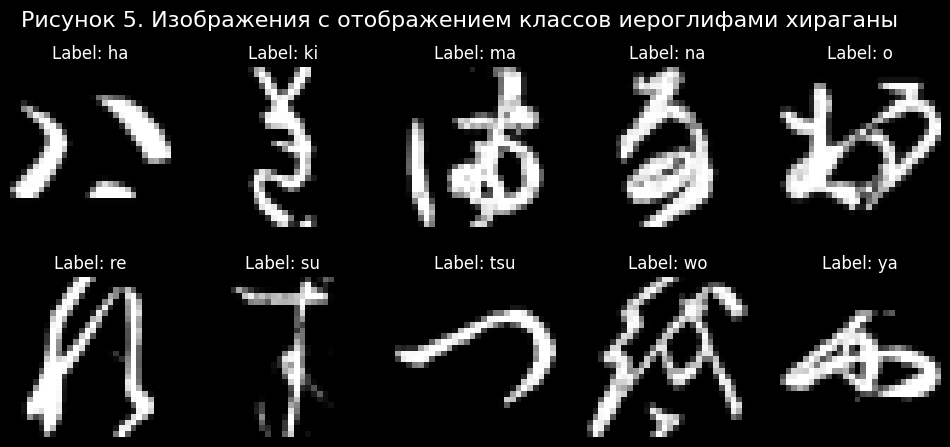

In [46]:
show_df_classes(df, "Рисунок 5. Изображения с отображением классов иероглифами хираганы")

In [ ]:

df.std()

TypeError: Cannot perform reduction 'std' with string dtype

In [47]:
from sklearn import PCA

ImportError: cannot import name 'PCA' from 'sklearn' (/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/__init__.py)